# Pie Charts

This notebook demonstrates the use of the `piechart` function which provides pretty label placement.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plot_misc.piechart as pychart
import plot_misc.example_data.examples as examples
from matplotlib.text import Annotation
from matplotlib.patches import Wedge

In [2]:
# Load example data -- Data is random! 
df = examples.load_percentage_data()
df

,labels,counts,percentages
0,PKP2 (10.0%),10,10.0
1,MYL2 (8.0%),8,8.0
2,JUP (5.0%),5,5.0
3,DSC2 (15.0%),15,15.0
4,DSG2 (13.0%),13,13.0
5,TTN (10.0%),10,10.0
6,DES (5.0%),5,5.0
7,DSP (10.0%),10,10.0
8,PLN (8.0%),8,8.0
9,RBM20 (10.0%),10,10.0


## Pie chart with pretty labels

Text(0.5, 1.1, 'HCM')

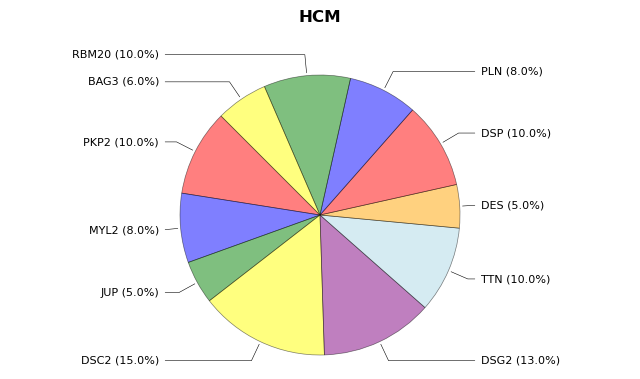

In [3]:
_, axes = pychart.piechart(df, col_values='percentages', col_labels='labels', colours=['red', 'blue', 'green', 'yellow', 'purple', 'lightblue', 'orange'])
axes.set_title('HCM', **{'fontsize': 12, 'y':1.10,'fontweight': 'bold'})

## Pie chart without labels
Use this to manually add labels, without connecting lines. 

Text(0.5, 1.05, 'HCM')

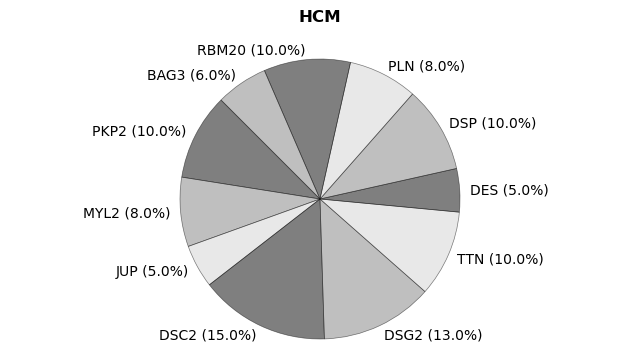

In [4]:
_, axes = pychart.piechart(df, col_values='percentages', col_labels=None, pie_kwargs={
    'labels': df['labels'].to_list(), 'labeldistance':1.07},
                          )
axes.set_title('HCM', **{'fontsize': 12, 'y':1.05,'fontweight': 'bold'})

### Removing labels and exploding a wedge
As an example here we will remove the _DSP_ label, and put some emphasize on the _TTN_ label by exploding it away from the other wedges.

Text(0.5, 1.1, 'HCM')

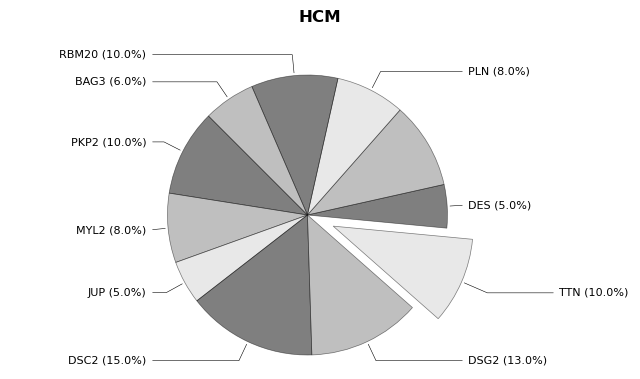

In [5]:
# explode TTN
explode = [0.2 if lab == 'TTN (10.0%)' else 0.0 for lab in df['labels']]
# adjust the xy text position for the exploded wedge
xypos_scaling = [(1.8, 1.4) if lab == 'TTN (10.0%)' else (1.15, 1.15) for lab in df['labels']]

_, axes = pychart.piechart(df, col_values='percentages', col_labels='labels', text_pos_scaling = xypos_scaling, pie_kwargs={'explode': explode})

# remove labels
wedges = [p for p in axes.patches if isinstance(p, Wedge)]
annotations = [t for t in axes.texts if isinstance(t, Annotation)]
for wedge, ann in zip(wedges, annotations):
    label_text = ann.get_text()  
    if label_text in ["DSP (10.0%)"]:
        #wedge.set_visible(False)
        ann.set_visible(False)
        
# add title
axes.set_title('HCM', **{'fontsize': 12, 'y':1.10,'fontweight': 'bold'})

In [6]:
help(pychart)

Help on module plot_misc.piechart in plot_misc:

NAME
    plot_misc.piechart - Pie chart plotting with flexible annotation control.

DESCRIPTION
    This module provides a `piechart` function to create labelled pie charts using
    `matplotlib`. It allows for full control over arrow and text positioning via
    scaling factors and provides mechanisms to handle exploded slices, tight label
    spacing, and custom annotation styling. The function integrates input validation,
    axis reuse, and visual tuning options such as wedge transparency, label placement,
    and arrow bending behaviour.
    
    Functions
    ---------
    piechart
        Draws a pie chart with optional annotations on an existing or new Axes,
        using customisable options for text and arrow positioning.

FUNCTIONS
    piechart(data: pandas.core.frame.DataFrame, col_values: str, col_labels: str | None = None, ax: matplotlib.axes._axes.Axes | None = None, figsize: tuple[float, float] = (8, 4), colours: list[str